Step by step decouple 
- `mlfromscratch/examples/polynomial_regression.py`
- `mlfromscratch/supervised_learning/regression.py`

Difference between Polynomial Regression and Lasso & Ridge Regression
- Polynomial Regression creates a more complex, curved model.
    - $y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3$
- Lasso and Ridge are **regularization** methods that simplify complex models to prevent overfitting.
    - **Lasso (L1)** adds a penalty ($|\beta|$), shrinks the high-degree coeff terms to zero (can reach zero)
    - **Ridge (L2)** adds a penalty ($\beta^2$), shrinks the high-degree coeff terms (like $\beta_3$ in $x^3$) near zero (cannot reach zero)


# Import

In [2]:
import os
import sys
sys.path.insert(0, "../..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlfromscratch.utils import k_fold_cross_validation_sets, normalize, mean_squared_error, r_square
from mlfromscratch.utils import train_test_split, polynomial_features, Plot

# enable automatic reloading of Python modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read Dataset

In [3]:
try:
    # when running as a script
    absdir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # when running in a Jupyter notebook (no __file__)
    absdir = os.getcwd()
data_filepath = os.path.join(absdir, "../..", "mlfromscratch/data/TempLinkoping2016.txt")
data = pd.read_csv(data_filepath, sep="\t")

In [4]:
data.head()

,time,temp
0,0.002732,0.1
1,0.005464,-4.5
2,0.008197,-6.3
3,0.010929,-9.6
4,0.013661,-9.9


## Select predictor and target

In [5]:
time = np.atleast_2d(data["time"].values).T
temp = data["temp"].values
X = time # fraction of the year [0, 1]
y = temp

## Plot Data

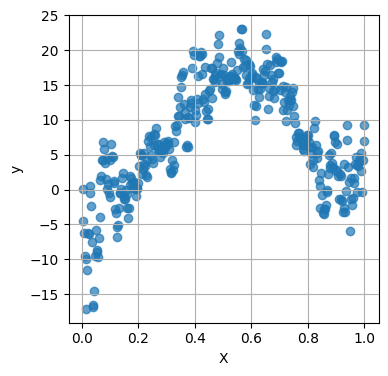

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(X.ravel(), y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Preprocess

In [7]:
# do a train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

# set poly degree
poly_degree = 15

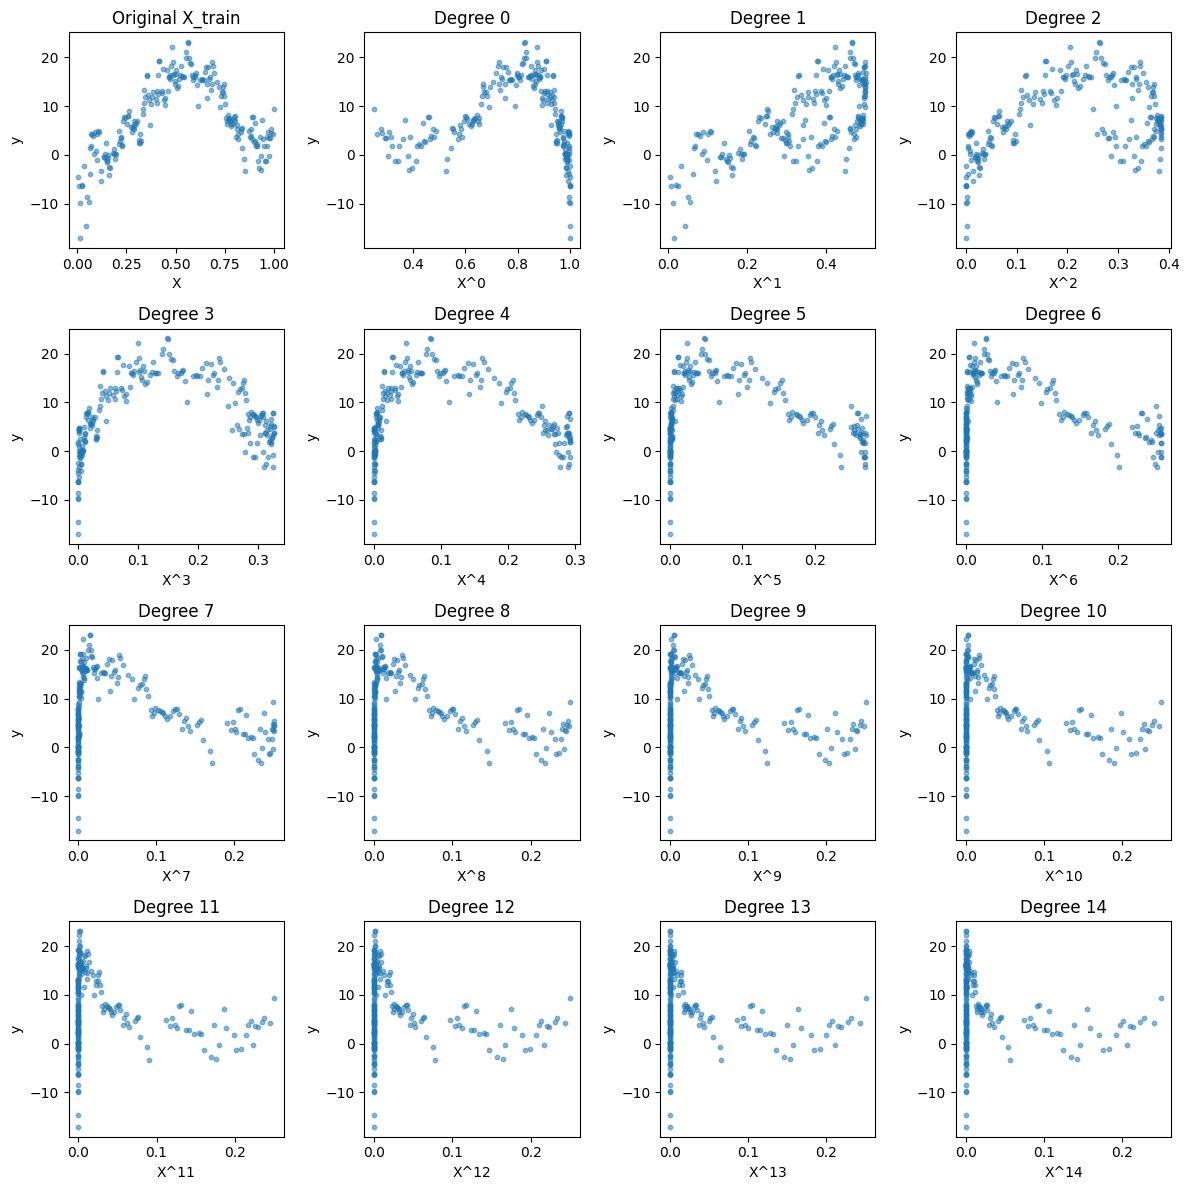

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

# plot original X_train
axes[0].scatter(X_train, y_train, alpha=0.5, s=10)
axes[0].set_title('Original X_train')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

# plot each polynomial degree feature
X_train_norm = normalize(polynomial_features(X_train, degree=poly_degree))
for i in range(X_train_norm.shape[1] - 1):
    axes[i+1].scatter(X_train_norm[:, i], y_train, alpha=0.5, s=10)
    axes[i+1].set_title(f'Degree {i}')
    axes[i+1].set_xlabel(f'X^{i}')
    axes[i+1].set_ylabel('y')

plt.tight_layout()
plt.show()

# Use Polynomial Regression Only

In [9]:
from mlfromscratch.supervised_learning import PolynomialRegression

k = 10
cross_validation_sets = k_fold_cross_validation_sets(
        X_train, y_train, k=k)
mse = 0
for _X_train, _X_test, _y_train, _y_test in cross_validation_sets:
    model = PolynomialRegression(degree=poly_degree, 
                                    learning_rate=0.001,
                                    n_iterations=10000)
    model.fit(_X_train, _y_train)
    y_pred = model.predict(_X_test)
    _mse = mean_squared_error(_y_test, y_pred)
    mse += _mse
mse /= k

# Print the mean squared error
print (f"\tK-Fold Mean Squared Error: {mse}")

	K-Fold Mean Squared Error: 10.589297117301255


In [16]:
# Make final prediction using full training data
model = PolynomialRegression(degree=poly_degree, 
                            learning_rate=0.001,
                            n_iterations=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse_no_reg = mean_squared_error(y_test, y_pred)
r2_no_reg = r_square(y_test, y_pred)
y_pred_line = model.predict(X)

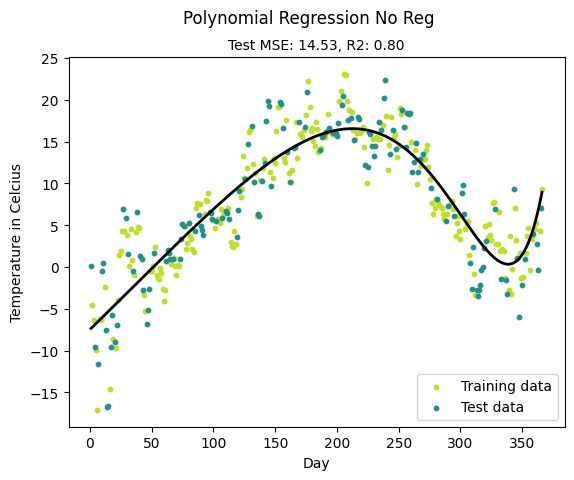

In [17]:
# Color map
cmap = plt.get_cmap('viridis')

# Plot the results
m1 = plt.scatter(366 * X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(366 * X_test, y_test, color=cmap(0.5), s=10)
plt.plot(366 * X, y_pred_line, color='black', linewidth=2, label="Prediction")
plt.suptitle("Polynomial Regression No Reg")
plt.title(f"Test MSE: {mse_no_reg:.2f}, R2: {r2_no_reg:.2f}", fontsize=10)
plt.xlabel('Day')
plt.ylabel('Temperature in Celcius')
plt.legend((m1, m2), ("Training data", "Test data"), loc='lower right')
plt.show()

# Use Polynomial Regression with L2 Reg

In [18]:
from mlfromscratch.supervised_learning import PolynomialRidgeRegression

lowest_error = float("inf")
best_reg_factor = None
print ("Finding regularization constant using cross validation:")
k = 10
results = []
for idx, reg_factor in enumerate(np.arange(0, 0.1, 0.01)):
    cross_validation_sets = k_fold_cross_validation_sets(
        X_train, y_train, k=k)
    mse = 0
    for _X_train, _X_test, _y_train, _y_test in cross_validation_sets:
        model = PolynomialRidgeRegression(degree=poly_degree, 
                                        reg_factor=reg_factor,
                                        learning_rate=0.001,
                                        n_iterations=10000)
        model.fit(_X_train, _y_train)
        y_pred = model.predict(_X_test)
        _mse = mean_squared_error(_y_test, y_pred)
        mse += _mse
    mse /= k

    # Print the mean squared error
    print (f"\tTrial {idx}: Mean Squared Error: {mse} (reg: {reg_factor})")

    # Save reg. constant that gave lowest error
    if mse < lowest_error:
        best_reg_factor = reg_factor
        lowest_error = mse
    results.append({"trial": idx, "mse": mse, "reg": reg_factor})
results = pd.DataFrame(results)

Finding regularization constant using cross validation:
	Trial 0: Mean Squared Error: 10.731200650063695 (reg: 0.0)
	Trial 1: Mean Squared Error: 10.496995132112446 (reg: 0.01)
	Trial 2: Mean Squared Error: 10.469017785806239 (reg: 0.02)
	Trial 3: Mean Squared Error: 10.629241625954228 (reg: 0.03)
	Trial 4: Mean Squared Error: 10.733038852934175 (reg: 0.04)
	Trial 5: Mean Squared Error: 10.740715117038508 (reg: 0.05)
	Trial 6: Mean Squared Error: 10.801454218295465 (reg: 0.06)
	Trial 7: Mean Squared Error: 10.815778434148125 (reg: 0.07)
	Trial 8: Mean Squared Error: 11.143285116426513 (reg: 0.08)
	Trial 9: Mean Squared Error: 10.91015661475925 (reg: 0.09)


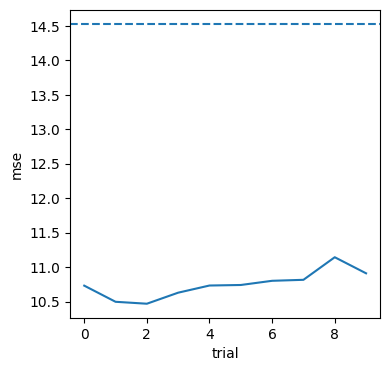

In [20]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.lineplot(results, x="trial", y="mse", ax=ax)
ax.axhline(y=mse_no_reg, linestyle="--", label="No Reg Test MSE")

In [26]:
# Make final prediction
model = PolynomialRidgeRegression(degree=poly_degree, 
                                reg_factor=best_reg_factor,
                                learning_rate=0.001,
                                n_iterations=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse_w_reg = mean_squared_error(y_test, y_pred)
r2_w_reg = r_square(y_test, y_pred)
print ("Mean squared error: %s (given by reg. factor: %s)" % (lowest_error, best_reg_factor))

y_pred_line = model.predict(X)

Mean squared error: 10.469017785806239 (given by reg. factor: 0.02)


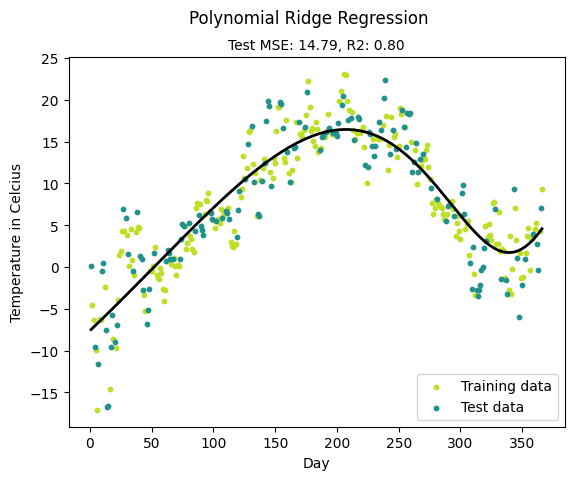

In [27]:
# Color map
cmap = plt.get_cmap('viridis')

# Plot the results
m1 = plt.scatter(366 * X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(366 * X_test, y_test, color=cmap(0.5), s=10)
plt.plot(366 * X, y_pred_line, color='black', linewidth=2, label="Prediction")
plt.suptitle("Polynomial Ridge Regression")
plt.title(f"Test MSE: {mse_w_reg:.2f}, R2: {r2_w_reg:.2f}", fontsize=10)
plt.xlabel('Day')
plt.ylabel('Temperature in Celcius')
plt.legend((m1, m2), ("Training data", "Test data"), loc='lower right')
plt.show()

Notice the tail is less extreme than without Regularization